In [2]:
from google.colab import drive
import zipfile
import os

# Monter Google Drive
drive.mount('/content/drive')

# Chemin du fichier sur le Drive
zip_path = '/content/drive/MyDrive/RARE25-train-data.zip'
# Dossier de destination sur le disque local Colab
extract_path = '/content/extracted_data'

if os.path.exists(zip_path):
    # Créer le dossier local s'il n'existe pas
    os.makedirs(extract_path, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        print(f"Extraction de {zip_path} vers {extract_path}...")
        zip_ref.extractall(extract_path)
        print("Extraction terminée.")

        # Afficher les premiers fichiers extraits pour vérification
        extracted_files = os.listdir(extract_path)
        print(f"Fichiers extraits (total {len(extracted_files)}) : {extracted_files[:10]}")
else:
    print(f"Erreur : Le fichier {zip_path} est introuvable. Vérifiez le nom dans votre Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extraction de /content/drive/MyDrive/RARE25-train-data.zip vers /content/extracted_data...
Extraction terminée.
Fichiers extraits (total 2) : ['center_2', 'center_1']



Dossier : center_2/ndbe (719 images trouvées)
Affichage de 3 échantillons...


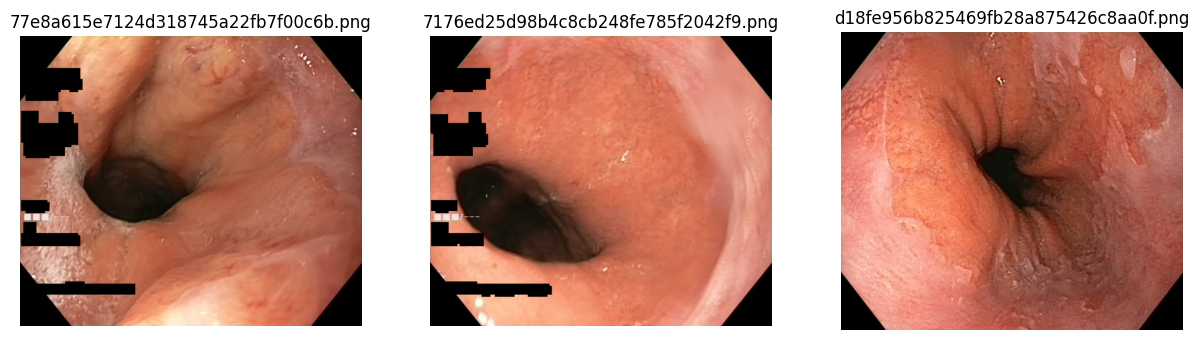


Dossier : center_2/neo (97 images trouvées)
Affichage de 3 échantillons...


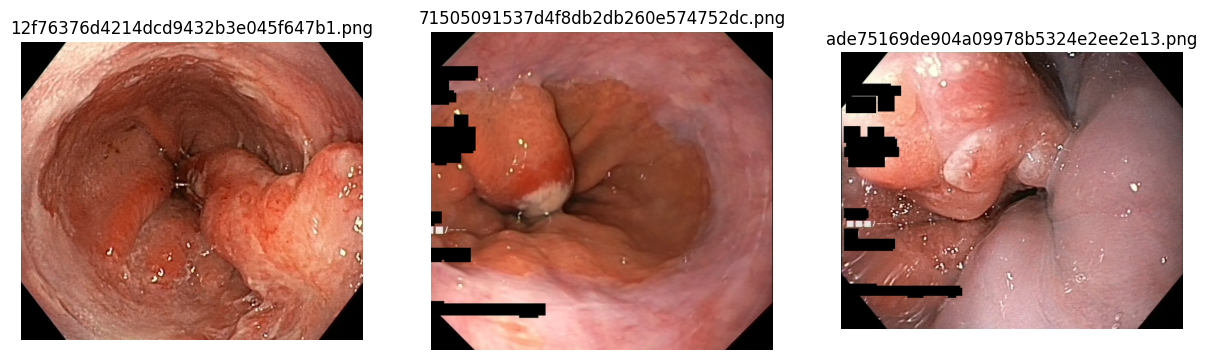


Dossier : center_1/ndbe (2218 images trouvées)
Affichage de 3 échantillons...


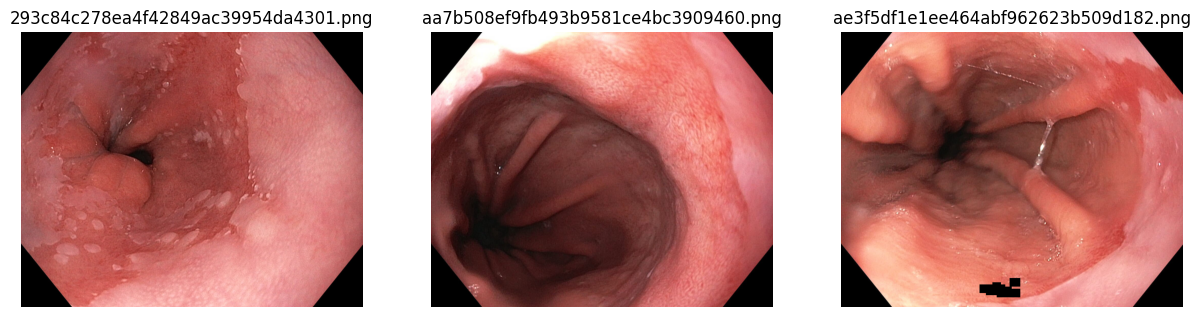


Dossier : center_1/neo (61 images trouvées)
Affichage de 3 échantillons...


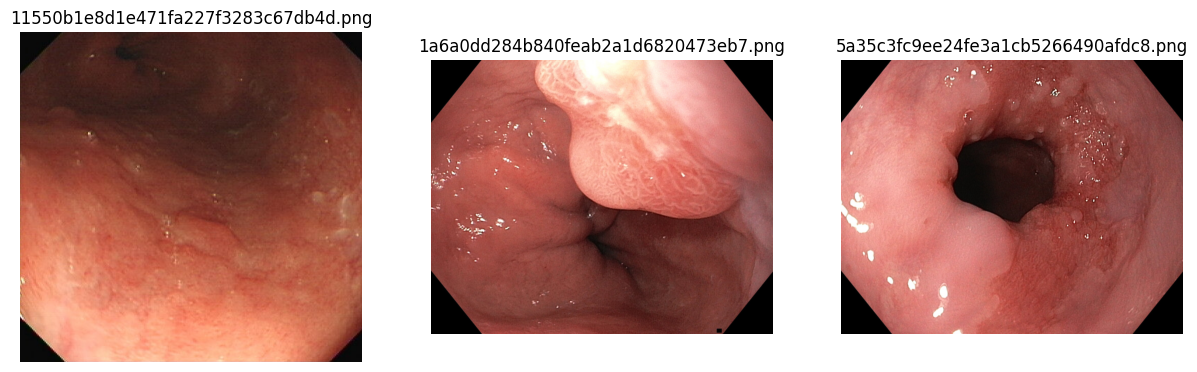

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import pathlib

def find_and_display_images(base_path, num_samples=3):
    # On cherche récursivement tous les fichiers avec des extensions d'image
    extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

    for root, dirs, files in os.walk(base_path):
        # On filtre les fichiers images dans le dossier actuel
        images = [f for f in files if f.lower().endswith(extensions)]

        if images:
            relative_path = os.path.relpath(root, base_path)
            print(f"\nDossier : {relative_path} ({len(images)} images trouvées)")
            print(f"Affichage de {min(num_samples, len(images))} échantillons...")

            plt.figure(figsize=(15, 5))
            for i in range(min(num_samples, len(images))):
                plt.subplot(1, num_samples, i + 1)
                img_path = os.path.join(root, images[i])
                try:
                    img = Image.open(img_path)
                    plt.imshow(img)
                    plt.title(images[i])
                    plt.axis('off')
                except Exception as e:
                    print(f"Erreur sur {images[i]}: {e}")
            plt.show()

find_and_display_images(extract_path)

,Path,Center,Category,Count
0,center_2/ndbe,center_2,ndbe,719
1,center_2/neo,center_2,neo,97
2,center_1/ndbe,center_1,ndbe,2218
3,center_1/neo,center_1,neo,61


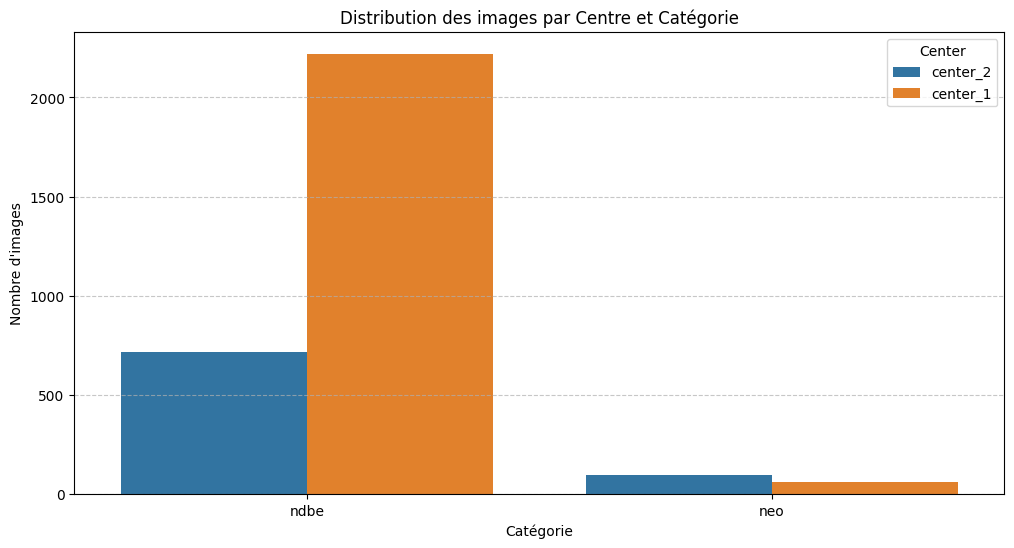

In [6]:
import pandas as pd
import seaborn as sns

def analyze_distribution(base_path):
    data = []
    extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

    for root, dirs, files in os.walk(base_path):
        images = [f for f in files if f.lower().endswith(extensions)]
        if images:
            relative_path = os.path.relpath(root, base_path)
            # Extraire le centre et la catégorie
            parts = relative_path.split(os.sep)
            center = parts[0] if len(parts) > 0 else 'Unknown'
            category = parts[1] if len(parts) > 1 else 'Root'

            data.append({
                'Path': relative_path,
                'Center': center,
                'Category': category,
                'Count': len(images)
            })

    df = pd.DataFrame(data)

    # Affichage du tableau récapitulatif
    display(df)

    # Visualisation
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df, x='Category', y='Count', hue='Center')
    plt.title('Distribution des images par Centre et Catégorie')
    plt.ylabel('Nombre d\'images')
    plt.xlabel('Catégorie')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    return df

distribution_df = analyze_distribution(extract_path)

### Analyse des dimensions des images
Cette étape permet de vérifier si les images ont des tailles uniformes ou variées, ce qui influence le choix de la stratégie de redimensionnement.

Statistiques des dimensions par catégorie :


width                                                            \
          count        mean        std    min    25%    50%    75%    max   
category                                                                    
ndbe      200.0  624.040000  39.728202  337.0  632.0  637.0  637.0  655.0   
neo       158.0  616.550633  53.602993  300.0  632.0  632.0  637.0  679.0   

         height              ...                ratio                      \
          count        mean  ...    75%    max  count      mean       std   
category                     ...                                            
ndbe      200.0  509.055000  ...  512.0  512.0  200.0  1.225217  0.051814   
neo       158.0  505.094937  ...  512.0  512.0  158.0  1.222146  0.060370   

                                                            
               min       25%       50%       75%       max  
category                                                    
ndbe      0.886842  1.234375  1.244141  1.244141  1.279297  
neo       0.992188  1.234375  1.234375  1.244141  1.466523  

[2 rows x 24 columns]

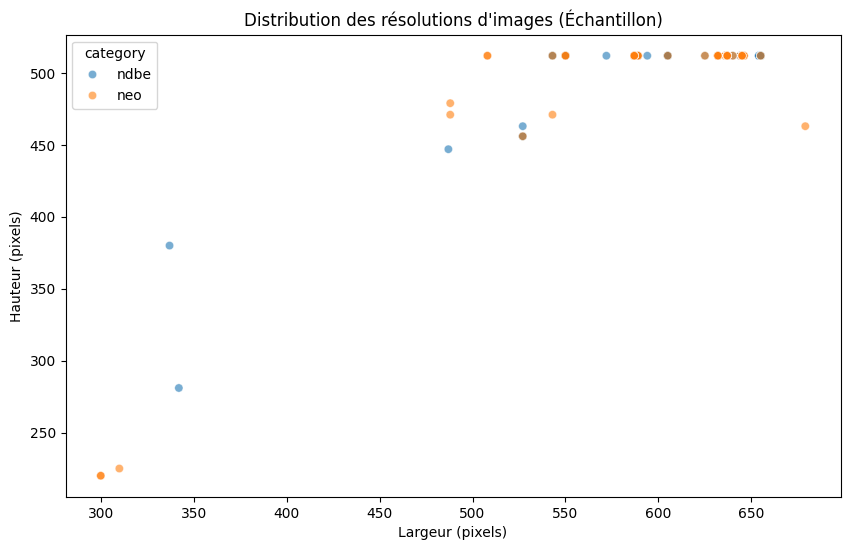

In [7]:
import numpy as np

def analyze_image_sizes(base_path, sample_size=100):
    image_data = []
    extensions = ('.jpg', '.jpeg', '.png')

    for root, dirs, files in os.walk(base_path):
        images = [f for f in files if f.lower().endswith(extensions)]
        if images:
            # Prendre un échantillon pour ne pas ralentir l'analyse
            sample = np.random.choice(images, min(len(images), sample_size), replace=False)

            for img_name in sample:
                path = os.path.join(root, img_name)
                try:
                    with Image.open(path) as img:
                        width, height = img.size
                        image_data.append({
                            'width': width,
                            'height': height,
                            'ratio': width/height,
                            'category': os.path.basename(root)
                        })
                except Exception as e:
                    continue

    return pd.DataFrame(image_data)

sizes_df = analyze_image_sizes(extract_path)

# Affichage des statistiques descriptives
print("Statistiques des dimensions par catégorie :")
display(sizes_df.groupby('category').describe())

# Visualisation des dimensions
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sizes_df, x='width', y='height', hue='category', alpha=0.6)
plt.title('Distribution des résolutions d\'images (Échantillon)')
plt.xlabel('Largeur (pixels)')
plt.ylabel('Hauteur (pixels)')
plt.show()

### Analyse de la distribution des couleurs (RGB)
Nous allons calculer la moyenne des intensités de pixels pour chaque canal (Rouge, Vert, Bleu) sur un échantillon d'images pour détecter d'éventuels biais colorimétriques entre les sources de données.

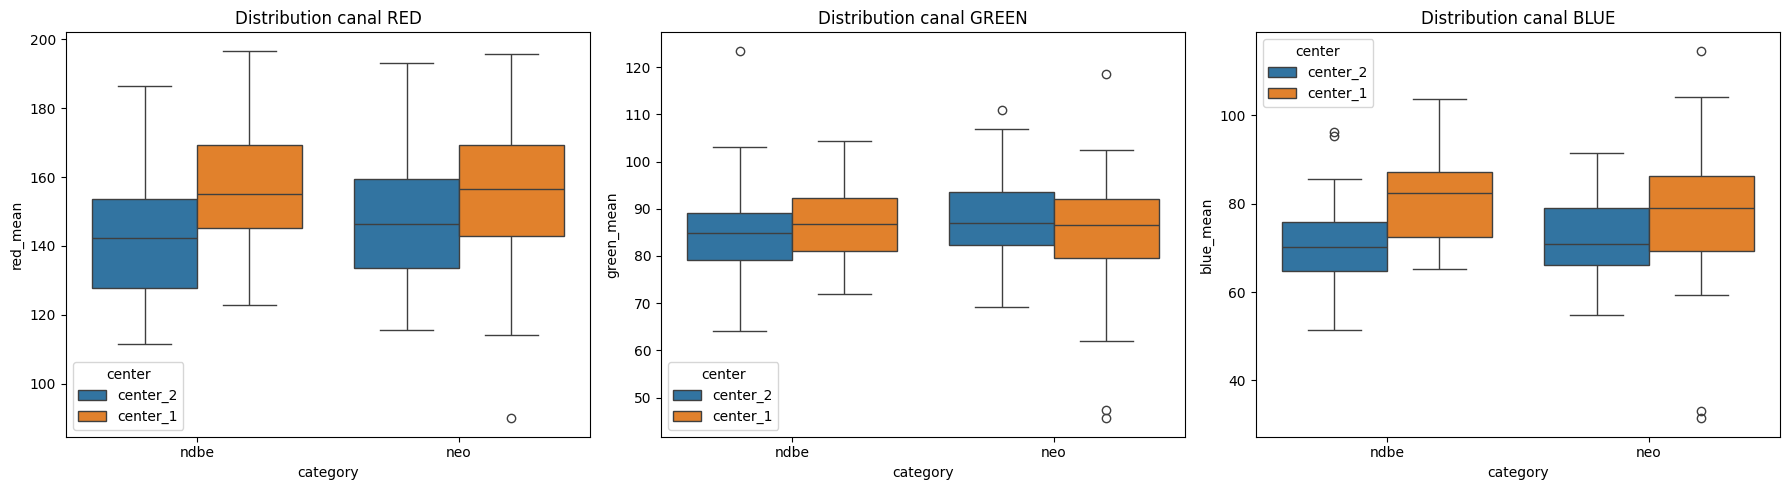

In [8]:
def analyze_color_distribution(base_path, sample_size=50):
    color_data = []
    extensions = ('.jpg', '.jpeg', '.png')

    for root, dirs, files in os.walk(base_path):
        images = [f for f in files if f.lower().endswith(extensions)]
        if images:
            sample = np.random.choice(images, min(len(images), sample_size), replace=False)
            category = os.path.basename(root)
            center = os.path.basename(os.path.dirname(root))

            for img_name in sample:
                path = os.path.join(root, img_name)
                try:
                    with Image.open(path).convert('RGB') as img:
                        img_array = np.array(img)
                        mean_rgb = img_array.mean(axis=(0, 1))
                        color_data.append({
                            'center': center,
                            'category': category,
                            'red_mean': mean_rgb[0],
                            'green_mean': mean_rgb[1],
                            'blue_mean': mean_rgb[2]
                        })
                except Exception:
                    continue
    return pd.DataFrame(color_data)

color_df = analyze_color_distribution(extract_path)

# Visualisation des moyennes de couleurs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
channels = ['red_mean', 'green_mean', 'blue_mean']
colors = ['red', 'green', 'blue']

for i, channel in enumerate(channels):
    sns.boxplot(ax=axes[i], data=color_df, x='category', y=channel, hue='center')
    axes[i].set_title(f'Distribution canal {channel.split("_")[0].upper()}')

plt.tight_layout()
plt.show()

### Consolidation du Dataset
Nous créons un index complet de toutes les images disponibles pour faciliter le futur partitionnement (Train/Val/Test) et l'application des transformations.

In [9]:
all_images = []
extensions = ('.jpg', '.jpeg', '.png')

for root, dirs, files in os.walk(extract_path):
    images = [f for f in files if f.lower().endswith(extensions)]
    if images:
        category = os.path.basename(root)
        center = os.path.basename(os.path.dirname(root))
        for img in images:
            all_images.append({
                'filepath': os.path.join(root, img),
                'center': center,
                'label': category
            })

dataset_df = pd.DataFrame(all_images)
print(f"Total d'images indexées : {len(dataset_df)}")
print(" Aperçu du dataset :")
display(dataset_df.head())

# Sauvegarde du CSV pour une utilisation ultérieure
dataset_df.to_csv('rare25_metadata.csv', index=False)
print("Fichier 'rare25_metadata.csv' sauvegardé.")

Total d'images indexées : 3095
 Aperçu du dataset :


,filepath,center,label
0,/content/extracted_data/center_2/ndbe/77e8a615...,center_2,ndbe
1,/content/extracted_data/center_2/ndbe/7176ed25...,center_2,ndbe
2,/content/extracted_data/center_2/ndbe/d18fe956...,center_2,ndbe
3,/content/extracted_data/center_2/ndbe/ccc5be41...,center_2,ndbe
4,/content/extracted_data/center_2/ndbe/c16019d1...,center_2,ndbe


Fichier 'rare25_metadata.csv' sauvegardé.


---
## 2. Préparation des données pour le pipeline ML

Conversion des labels texte → binaire (`ndbe` = 0, néoplasie = 1) et création du split stratifié **train / val_selection / val_calibration** (85 % / 10.5 % / 4.5 %).

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit

df = pd.read_csv('rare25_metadata.csv')
df = df.rename(columns={'filepath': 'image_path'})

print('Catégories détectées :', df['label'].unique())

NEGATIVE_CLASS = 'ndbe'
df['label'] = (df['label'] != NEGATIVE_CLASS).astype(int)

n_pos, n_neg = df['label'].sum(), (df['label'] == 0).sum()
print(f'Positifs (néoplasie) : {n_pos}  |  Négatifs (ndbe) : {n_neg}')

os.makedirs('/content/data', exist_ok=True)

# Split stratifié 85 / 15 %
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, val_idx = next(sss.split(np.zeros(len(df)), df['label'].values))
train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)

# val → val_selection (70 %) + val_calibration (30 %)
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
sel_idx, cal_idx = next(sss2.split(np.zeros(len(val_df)), val_df['label'].values))
val_sel_df = val_df.iloc[sel_idx].reset_index(drop=True)
val_cal_df = val_df.iloc[cal_idx].reset_index(drop=True)

train_df.to_csv('/content/data/train.csv',            index=False)
val_df.to_csv('/content/data/val.csv',                index=False)
val_sel_df.to_csv('/content/data/val_selection.csv',  index=False)
val_cal_df.to_csv('/content/data/val_calibration.csv',index=False)

print()
for name, d in [('train', train_df), ('val_selection', val_sel_df), ('val_calibration', val_cal_df)]:
    print(f'  {name:<18}: {len(d):4d} images  (pos={d["label"].sum():3d}, neg={(d["label"]==0).sum():4d})')
print('\n✓ CSVs sauvegardés dans /content/data/')


---
## 3. Setup — Clonage du repo et installation des dépendances

In [ ]:
# Cloner le repo depuis GitHub
!git clone https://github.com/hashirama21/neoplasia-detection.git /content/rare26

%cd /content/rare26

!pip install -r requirements.txt -q
print('\n✓ Repo cloné et dépendances installées.')


In [ ]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'✓ GPU : {gpu_name}  ({gpu_mem:.1f} GB)')
else:
    print('⚠ Pas de GPU. Activer : Runtime → Changer le type d\'exécution → GPU')


### Poids GastroNet-5M (optionnel mais recommandé)

Backbone DINOv2 ViT-Base pré-entraîné sur 5 M d'images endoscopiques.  
Sans ces poids, le modèle démarre depuis une initialisation aléatoire (performances dégradées).

In [ ]:
from pathlib import Path

WEIGHTS_PATH = Path('/content/rare26/weights/dinov2_gastronet5m.pth')
WEIGHTS_PATH.parent.mkdir(exist_ok=True)

if WEIGHTS_PATH.exists():
    print(f'✓ Poids déjà présents : {WEIGHTS_PATH}')
else:
    try:
        from huggingface_hub import hf_hub_download
        hf_hub_download(
            repo_id='BONS-AI-TUE-AMC/GastroNetDinov2',
            filename='dinov2_gastronet5m.pth',
            local_dir=str(WEIGHTS_PATH.parent),
        )
        print(f'✓ Poids téléchargés : {WEIGHTS_PATH}')
    except Exception as e:
        print(f'⚠  Téléchargement échoué : {e}')
        print('   Le modèle utilisera une initialisation aléatoire ViT-Base/14.')


---
## 4. Entraînement

**Durée estimée :** 30–60 min selon le GPU (T4 ≈ 50 min, A100 ≈ 15 min pour 20 epochs).  
La calibration isotonique et la recherche de seuil optimal sont exécutées **automatiquement** en fin d'entraînement via `train.py`.

In [ ]:
OUTPUT = '/content/outputs'

!python scripts/train.py \
    project.output_dir={OUTPUT} \
    paths.data_dir=/content/data \
    paths.weights_dir=/content/rare26/weights \
    device={device} \
    num_workers=2 \
    pin_memory=false \
    training.epochs=20 \
    training.cross_validation.enabled=false \
    training.loss.gamma_neg=4


---
## 5. Résultats de calibration

Les artefacts (calibrateur isotonique + seuil optimal) sont sauvegardés dans `outputs/results/`.
Le script standalone `calibrate.py` permet de recalibrer sans réentraîner.

In [ ]:
import json
from pathlib import Path

results_path = Path(f'{OUTPUT}/results/calibration_results.json')
if results_path.exists():
    with open(results_path) as f:
        cal = json.load(f)
    print('Résultats de calibration (val_calibration) :')
    print(f"  Méthode        : {cal.get('method', 'isotonic')}")
    print(f"  Seuil optimal  : {cal.get('optimal_threshold', 'N/A'):.4f}")
    print(f"  Median PPV@90R : {cal.get('median_ppv', 0):.4f}")
    print(f"  Median Recall  : {cal.get('median_recall', 0):.4f}")
    print(f"  PPV std        : {cal.get('std_ppv', 0):.4f}")
else:
    print(f'⚠ {results_path} introuvable. Vérifiez que l\'entraînement s\'est terminé.')


---
## 6. Évaluation officielle (bootstrap)

Reproduit la procédure officielle RARE26 sur `val_selection` : 1 000 itérations bootstrap à 1 % de prévalence.  
⚠ On évalue sur `val_selection` (jamais sur `val_calibration`, utilisé pour le seuil).

In [ ]:
!python scripts/evaluate.py \
    project.output_dir={OUTPUT} \
    paths.data_dir=/content/data \
    paths.weights_dir=/content/rare26/weights \
    device={device} \
    num_workers=2 \
    pin_memory=false


In [ ]:
import json, pandas as pd
from pathlib import Path
from IPython.display import display

eval_path = Path(f'{OUTPUT}/results/evaluation_results.json')
if eval_path.exists():
    with open(eval_path) as f:
        ev = json.load(f)
    df_ev = pd.DataFrame([
        {'Métrique': k.replace('_', ' ').title(), 'Valeur': f'{v:.4f}'}
        for k, v in ev.items()
    ])
    display(df_ev.set_index('Métrique'))
else:
    print(f'⚠ {eval_path} introuvable.')


---
## 7. Démonstration d'inférence

Prédiction sur 4 images aléatoires du dataset avec le modèle calibré.

In [ ]:
import glob, json, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as T
from pathlib import Path
from PIL import Image

import sys
sys.path.insert(0, '/content/rare26')
from src.models.rare26_model import Rare26Model
from src.calibration.calibrator import IsotonicCalibrator
from omegaconf import OmegaConf

OUTPUT = '/content/outputs'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Meilleur checkpoint
ckpts = sorted(
    glob.glob(f'{OUTPUT}/checkpoints/*.pt'),
    key=lambda p: float(Path(p).stem.rsplit('_', 1)[-1]),
    reverse=True,
)
if not ckpts:
    print('⚠ Aucun checkpoint — lancez l\'entraînement d\'abord.')
else:
    # Charger le modèle
    model_cfg = OmegaConf.load('/content/rare26/configs/model/dinov2_gastronet.yaml')
    OmegaConf.update(model_cfg, 'checkpoint_path', '', merge=True)
    model = Rare26Model(model_cfg).to(device)
    ckpt = torch.load(ckpts[0], map_location=device, weights_only=True)
    model.load_state_dict(ckpt['model_state'])
    model.eval()

    # Calibrateur et seuil
    cal_pkl  = Path(f'{OUTPUT}/results/isotonic_calibrator.pkl')
    cal_json = Path(f'{OUTPUT}/results/calibration_results.json')
    calibrator = None
    threshold  = 0.5
    if cal_pkl.exists():
        calibrator = IsotonicCalibrator()
        calibrator.load(str(cal_pkl))
    if cal_json.exists():
        with open(cal_json) as f:
            threshold = json.load(f).get('optimal_threshold', 0.5)

    # Transformation de validation
    transform = T.Compose([
        T.Resize(336, interpolation=T.InterpolationMode.BICUBIC),
        T.CenterCrop(336),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # 4 images aléatoires
    all_imgs = glob.glob('/content/extracted_data/**/*.jpg', recursive=True) + \
               glob.glob('/content/extracted_data/**/*.png', recursive=True)
    samples = random.sample(all_imgs, min(4, len(all_imgs)))

    fig, axes = plt.subplots(1, len(samples), figsize=(16, 4))
    if len(samples) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, samples):
        img = Image.open(img_path).convert('RGB')
        with torch.no_grad():
            tensor = transform(img).unsqueeze(0).to(device)
            logit  = model(tensor).squeeze().item()
        raw_prob = 1 / (1 + np.exp(-logit))
        cal_prob = float(calibrator.transform(np.array([raw_prob]))[0]) \
                   if calibrator else raw_prob
        pred     = cal_prob >= threshold
        true_cls = 'neoplasie' if 'ndbe' not in Path(img_path).parent.name else 'ndbe'

        ax.imshow(img)
        color = 'red' if pred else 'green'
        ax.set_title(
            f'Réel : {true_cls}\nProb : {cal_prob:.3f}  →  {"⚠ NÉOPLASIE" if pred else "✓ NDBE"}',
            color=color, fontsize=9,
        )
        ax.axis('off')

    plt.suptitle(f'Inférence — seuil calibré : {threshold:.3f}', fontsize=12)
    plt.tight_layout()
    plt.show()
